<a href="https://colab.research.google.com/github/Gunasalini/student-performance-data-science/blob/main/Week_4_Machine_Learning_Model_Development_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving student+performance.zip to student+performance.zip


In [4]:
import zipfile
import os

with zipfile.ZipFile("student+performance.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print(os.listdir("student_data"))
with zipfile.ZipFile("student_data/student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data/extracted")

print(os.listdir("student_data/extracted"))
for root, dirs, files in os.walk("student_data"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

['student.zip', '.student.zip_old']
['student-merge.R', 'student-por.csv', 'student-mat.csv', 'student.txt']
student_data/extracted/student-por.csv
student_data/extracted/student-mat.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [6]:
# Load the Mathematics dataset
mat_df = pd.read_csv(
    "student_data/extracted/student-mat.csv",
    sep=";"
)

# Load the Portuguese dataset
por_df = pd.read_csv(
    "student_data/extracted/student-por.csv",
    sep=";"
)

# Add subject labels
mat_df["subject"] = "Mathematics"
por_df["subject"] = "Portuguese"

# Combine both datasets
df = pd.concat(
    [mat_df, por_df],
    ignore_index=True
)

print("Mathematics records:", len(mat_df))
print("Portuguese records:", len(por_df))
print("Combined records:", len(df))

Mathematics records: 395
Portuguese records: 649
Combined records: 1044


In [7]:
# Check the dataset structure
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (1044, 34)

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Mathematics
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Mathematics
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Mathematics
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Mathematics
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Mathematics


In [8]:
# Create the binary target variable
df["performance"] = np.where(
    df["G3"] >= 12,
    1,
    0
)

# Check the distribution of the target
print("Performance group counts:")
print(df["performance"].value_counts())

print("\nPerformance group percentages:")
print(
    df["performance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Performance group counts:
performance
0    534
1    510
Name: count, dtype: int64

Performance group percentages:
performance
0    51.15
1    48.85
Name: proportion, dtype: float64


In [9]:
# Check the relationship between G3 and the new target
print(
    df[["G3", "performance"]]
    .head(10)
)

   G3  performance
0   6            0
1   6            0
2  10            0
3  15            1
4  10            0
5  15            1
6  11            0
7   6            0
8  19            1
9  15            1


In [10]:
# Display target distribution clearly

target_counts = df["performance"].value_counts().sort_index()

print("Lower Performance (0):", target_counts[0])
print("Higher Performance (1):", target_counts[1])

print("\nPercentage distribution:")
print(
    df["performance"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Lower Performance (0): 534
Higher Performance (1): 510

Percentage distribution:
performance
0    51.15
1    48.85
Name: proportion, dtype: float64


In [11]:
# Select features for the machine learning model

features = [
    "age",
    "studytime",
    "failures",
    "absences",
    "Medu",
    "Fedu",
    "traveltime",
    "goout",
    "health",
    "famrel",
    "freetime"
]

X = df[features]
y = df["performance"]

print("Number of features:", len(features))
print("\nFeatures used:")
print(features)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Number of features: 11

Features used:
['age', 'studytime', 'failures', 'absences', 'Medu', 'Fedu', 'traveltime', 'goout', 'health', 'famrel', 'freetime']

Feature matrix shape: (1044, 11)
Target shape: (1044,)


In [13]:
# Check for missing values

missing_values = X.isnull().sum()

print("Missing values in each feature:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Missing values in each feature:
age           0
studytime     0
failures      0
absences      0
Medu          0
Fedu          0
traveltime    0
goout         0
health        0
famrel        0
freetime      0
dtype: int64

Total missing values: 0
Number of duplicate rows: 0


In [14]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training samples: 835
Testing samples: 209

Training class distribution:
performance
0    51.14
1    48.86
Name: proportion, dtype: float64

Testing class distribution:
performance
0    51.2
1    48.8
Name: proportion, dtype: float64


In [15]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:", X_train_scaled.shape)
print("Testing data after scaling:", X_test_scaled.shape)

Training data after scaling: (835, 11)
Testing data after scaling: (209, 11)


In [16]:
# Create and train the Logistic Regression model

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [17]:
# Generate predictions on the unseen test data

y_pred = logistic_model.predict(X_test_scaled)

# Generate predicted probabilities for ROC-AUC
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 209


In [19]:
# Calculate model performance metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
# Detailed classification report

print("Classification Report")
print("---------------------")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Lower Performance",
            "Higher Performance"
        ]
    )
)

Logistic Regression Performance
--------------------------------
Accuracy : 0.6507
Precision: 0.6283
Recall   : 0.6961
F1-Score : 0.6605
ROC-AUC  : 0.7076
Classification Report
---------------------
                    precision    recall  f1-score   support

 Lower Performance       0.68      0.61      0.64       107
Higher Performance       0.63      0.70      0.66       102

          accuracy                           0.65       209
         macro avg       0.65      0.65      0.65       209
      weighted avg       0.65      0.65      0.65       209



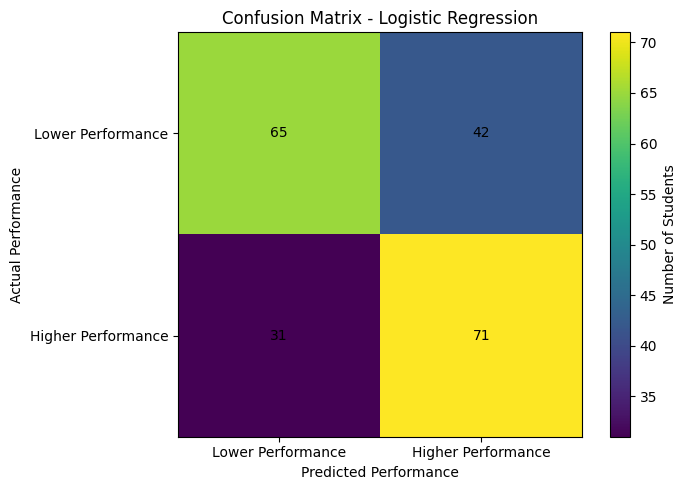

In [20]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Performance")
plt.ylabel("Actual Performance")

plt.xticks(
    [0, 1],
    ["Lower Performance", "Higher Performance"]
)

plt.yticks(
    [0, 1],
    ["Lower Performance", "Higher Performance"]
)

# Add the numbers to the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of Students")
plt.tight_layout()
plt.show()

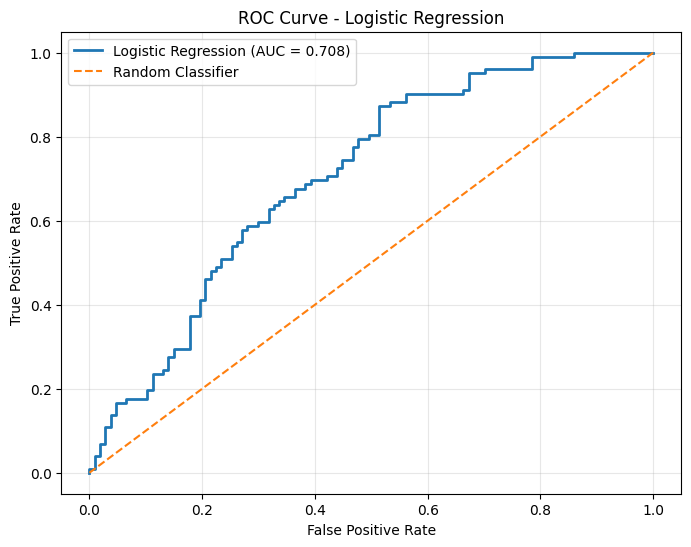

In [21]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [22]:
# Compare training and testing performance

train_pred = logistic_model.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy :", round(test_accuracy, 4))
print("Accuracy Difference:", round(train_accuracy - test_accuracy, 4))

Training Accuracy: 0.6886
Testing Accuracy : 0.6507
Accuracy Difference: 0.0379


In [23]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
tree_model.fit(X_train, y_train)

# Generate predictions
tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [25]:
# Evaluate Decision Tree performance

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred)
tree_recall = recall_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)
tree_roc_auc = roc_auc_score(y_test, tree_prob)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1-Score : {tree_f1:.4f}")
print(f"ROC-AUC  : {tree_roc_auc:.4f}")
# Compare both models

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Decision Tree": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_roc_auc
    ]
})

comparison.round(4)

Decision Tree Performance
-------------------------
Accuracy : 0.6124
Precision: 0.5802
Recall   : 0.7451
F1-Score : 0.6524
ROC-AUC  : 0.6201


,Metric,Logistic Regression,Decision Tree
0,Accuracy,0.6507,0.6124
1,Precision,0.6283,0.5802
2,Recall,0.6961,0.7451
3,F1-Score,0.6605,0.6524
4,ROC-AUC,0.7076,0.6201


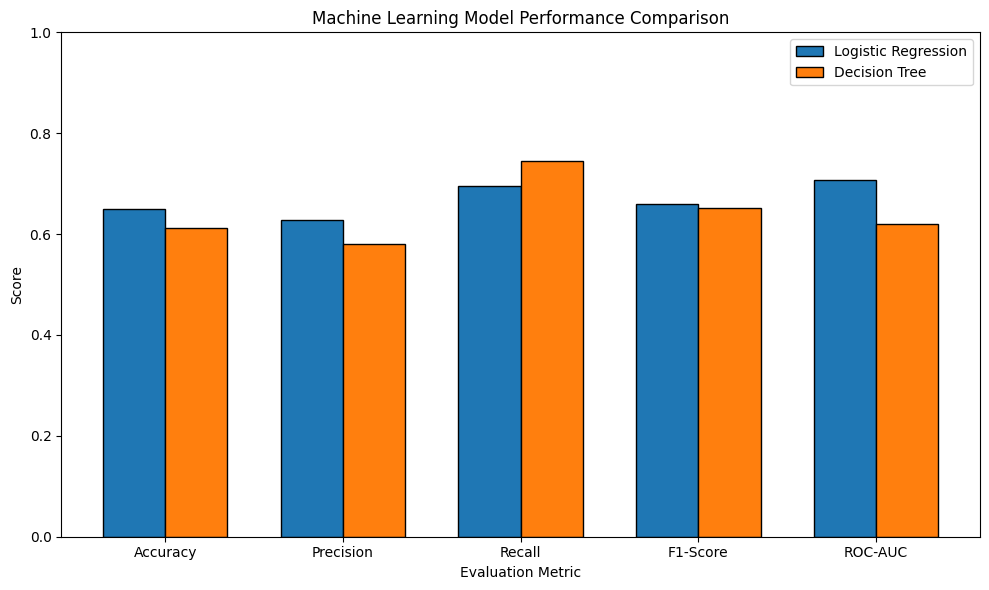

In [26]:
# Prepare data for visualization

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

logistic_scores = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

tree_scores = [
    tree_accuracy,
    tree_precision,
    tree_recall,
    tree_f1,
    tree_roc_auc
]

x = np.arange(len(metrics))
width = 0.35

# Create grouped bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    logistic_scores,
    width,
    label="Logistic Regression",
    edgecolor="black"
)

plt.bar(
    x + width / 2,
    tree_scores,
    width,
    label="Decision Tree",
    edgecolor="black"
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# Examine Logistic Regression coefficients

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Logistic Regression Feature Coefficients:")
display(coefficients)

Logistic Regression Feature Coefficients:


,Feature,Coefficient,Absolute_Coefficient
2,failures,-0.936242,0.936242
3,absences,-0.271801,0.271801
4,Medu,0.221807,0.221807
6,traveltime,-0.219089,0.219089
8,health,-0.213387,0.213387
1,studytime,0.197244,0.197244
5,Fedu,0.185575,0.185575
7,goout,-0.157198,0.157198
9,famrel,0.093741,0.093741
10,freetime,-0.077461,0.077461


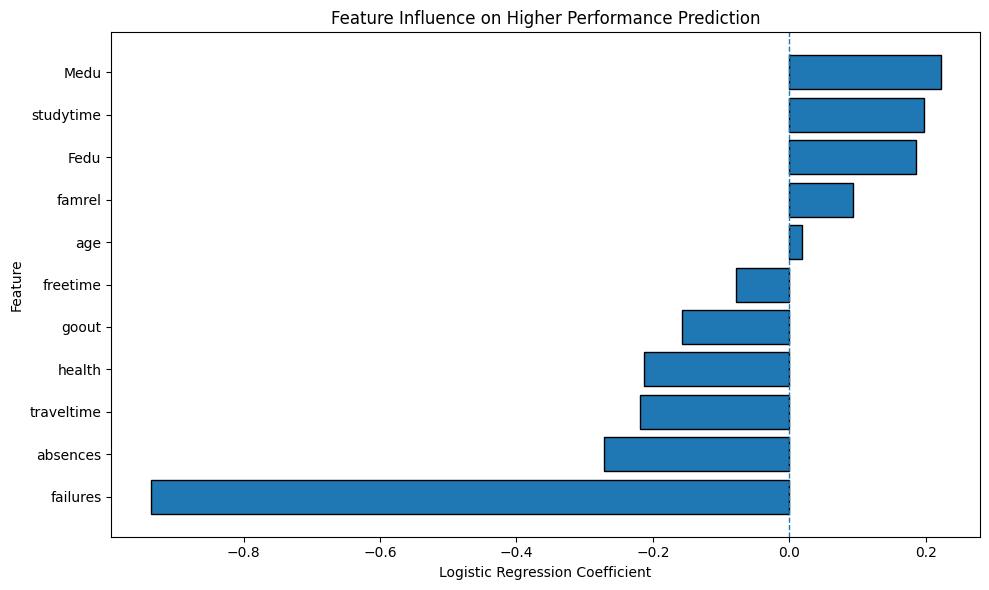

In [28]:
# Visualize Logistic Regression coefficients

plot_data = coefficients.sort_values("Coefficient")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"],
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Feature Influence on Higher Performance Prediction")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [29]:
# Detailed error analysis for Logistic Regression

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

total = tn + fp + fn + tp

print("Error Analysis")
print("--------------")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nError Rates")
print(f"False Positive Rate: {fp / (fp + tn):.4f}")
print(f"False Negative Rate: {fn / (fn + tp):.4f}")
print(f"Overall Error Rate : {(fp + fn) / total:.4f}")

Error Analysis
--------------
True Negatives : 65
False Positives: 42
False Negatives: 31
True Positives : 71

Error Rates
False Positive Rate: 0.3925
False Negative Rate: 0.3039
Overall Error Rate : 0.3493


## Final Conclusion

The objective of this project was to develop a machine learning model to classify students into Lower Performance and Higher Performance groups using student-related features. Logistic Regression was selected as the main model and was compared with a Decision Tree.

The Logistic Regression model achieved 65.07% accuracy, 62.83% precision, 69.61% recall, 66.05% F1-score, and a ROC-AUC of 0.7076 on the test data. The confusion matrix showed 65 true negatives, 42 false positives, 31 false negatives, and 71 true positives.

Compared with Logistic Regression, the Decision Tree achieved lower accuracy (61.24%) and ROC-AUC (0.6201), although it had higher recall (74.51%). Based on the overall results, Logistic Regression was selected as the preferred model.

The training accuracy was 68.86% compared with 65.07% testing accuracy, giving a difference of 3.79 percentage points. This relatively small gap does not indicate severe overfitting. However, the model still produced an overall error rate of 34.93%, showing that its predictions are not perfect.

The analysis also showed that previous failures had the strongest model coefficient, followed by absences, parental education, travel time, health, and study time. These results represent associations used by the model and should not be interpreted as proof of causation.

Future improvements could include testing additional algorithms, tuning model parameters, using more features, and applying cross-validation to obtain a more robust estimate of model performance.